In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("resumes.csv")

# Target column
df['Selected'] = df['Skills'].apply(lambda x: 1 if 'Python' in x else 0)

import random
for i in random.sample(range(len(df)), int(0.2 * len(df))):
    df.loc[i, 'Selected'] = 1 - df.loc[i, 'Selected']

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['Skills'])
y = df['Selected']

# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Convert to 0/1
y_pred = [1 if i > 0.5 else 0 for i in y_pred]

# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Linear Regression Accuracy:", accuracy)

Linear Regression Accuracy: 0.79


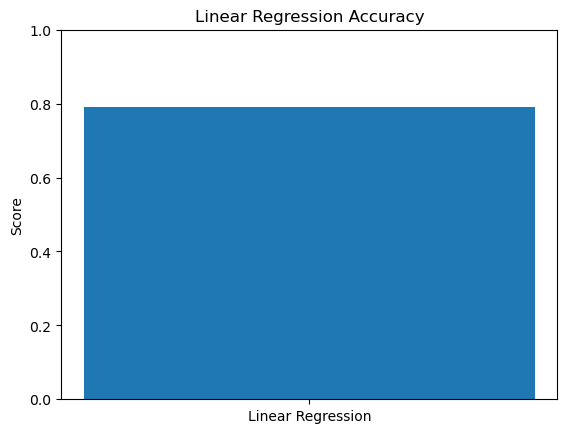

In [2]:
import matplotlib.pyplot as plt

plt.bar(['Linear Regression'], [accuracy])
plt.title("Linear Regression Accuracy")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()